# Import libraries

In [ ]:
import pandas as pd
import numpy as np
from os.path import join as pjoin
import matplotlib.pyplot as plt
from scipy.stats import sem
from spks.event_aligned import population_peth
from spks.utils import alpha_function
from spks.viz import plot_event_aligned_raster

pd.set_option("display.max_columns", 100)

plt.rcParams["text.usetex"] = False
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.size"] = 12
plt.rcParams["figure.dpi"] = 100

%config InlineBackend.figure_format = 'svg'
%matplotlib widget
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data

In [38]:
# %% Load data
animal = "GRB006"  # example animal
session = "20240821_121447"  # example session

data_dir = "/Users/gabriel/data"
trial_ts = pd.read_pickle(
    pjoin(data_dir, animal, session, "pre_processed", "trial_ts.pkl")
)
spike_times_per_unit = np.load(
    pjoin(data_dir, animal, session, "pre_processed", "spike_times_per_unit.npy"),
    allow_pickle=True,
)

trial_ts = trial_ts[
    trial_ts["stationary_stims"].apply(lambda x: len(x) > 0)
    & trial_ts["movement_stims"].apply(lambda x: len(x) > 0)
    & trial_ts["center_port_entries"].apply(lambda x: len(x) > 0)
].copy()

# Set up variables

In [39]:
first_stim = trial_ts["first_stim_ts"].to_numpy()

binwidth_ms = 10
pre_seconds = 0.1
post_seconds = 0.15

t_decay = 0.025
t_rise = 0.001
decay = t_decay / (binwidth_ms / 1000)
kern = alpha_function(
    int(decay * 15), t_rise=t_rise, t_decay=decay, srate=1.0 / (binwidth_ms / 1000)
)  # this kernel is for smoothing PETHs later

# Visualize raster

In [40]:
bpod = pd.read_pickle("/Users/gabriel/Downloads/20240821_121447_bpod_ts.pkl")

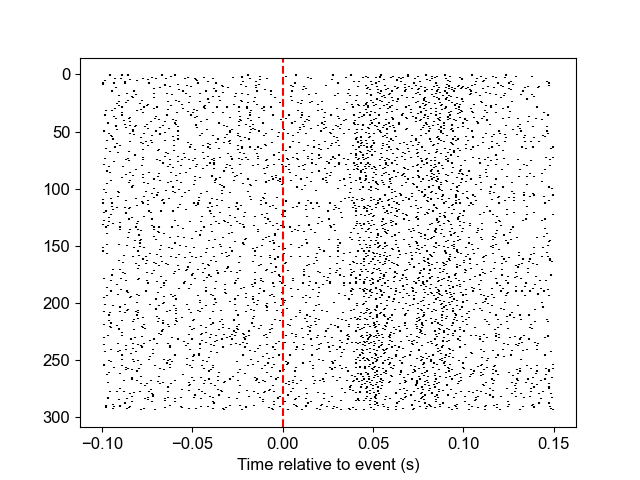

In [42]:
fig, ax = plt.subplots(1)
plot_event_aligned_raster(
    event_times=np.hstack(bpod.stim_ts.apply(lambda x: x[0])),
    spike_times=spike_times_per_unit[77],
    pre_seconds=pre_seconds,
    post_seconds=post_seconds,
    ax=ax,
)

ymin, ymax = ax.get_ylim()
ax.vlines(x=0, ymin=ymin, ymax=ymax, colors="r", linestyles="--");

# Compute and visualize PETH

(149, 294, 23)
(149, 287, 23)


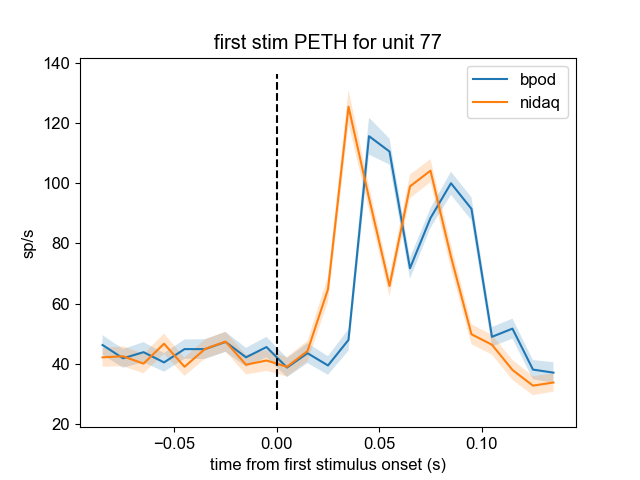

In [43]:
peth, timebin_edges, event_index = population_peth(
    all_spike_times=spike_times_per_unit,
    alignment_times=np.hstack(bpod.stim_ts.apply(lambda x: x[0])),
    pre_seconds=pre_seconds,
    post_seconds=post_seconds,
    binwidth_ms=10,
    kernel=None,
    pad=0,
)

n_units, n_trials, n_timepoints = peth.shape
print(peth.shape)

mean_peth = np.mean(peth, axis=1)  # average across trials
sem_peth = sem(peth, axis=1)  # calculate the SEM across trials

unit_id = 77
peth_73 = mean_peth[unit_id].copy()
sem_73 = sem_peth[unit_id].copy()

fig, ax = plt.subplots(1)
bin_centers = (timebin_edges[:-1] + timebin_edges[1:]) / 2.0
ax.plot(bin_centers, peth_73, label="bpod")
ax.fill_between(bin_centers, y1=peth_73 - sem_73, y2=peth_73 + sem_73, alpha=0.2)

ymin, ymax = ax.get_ylim()
# ax.vlines(x=0, ymin=ymin, ymax=ymax, colors="k", linestyles="--")
ax.set_title((f"first stim PETH for unit {unit_id}"))

peth, timebin_edges, event_index = population_peth(
    all_spike_times=spike_times_per_unit,
    alignment_times=first_stim,
    pre_seconds=pre_seconds,
    post_seconds=post_seconds,
    binwidth_ms=10,
    kernel=None,
    pad=0,
)

n_units, n_trials, n_timepoints = peth.shape
print(peth.shape)

mean_peth = np.mean(peth, axis=1)  # average across trials
sem_peth = sem(peth, axis=1)  # calculate the SEM across trials

# unit_id = 77
peth_73 = mean_peth[unit_id].copy()
sem_73 = sem_peth[unit_id].copy()

# fig, ax = plt.subplots(1)
bin_centers = (timebin_edges[:-1] + timebin_edges[1:]) / 2.0
ax.plot(bin_centers, peth_73, label="nidaq")
ax.fill_between(bin_centers, y1=peth_73 - sem_73, y2=peth_73 + sem_73, alpha=0.2)

ymin, ymax = ax.get_ylim()
ax.vlines(x=0, ymin=ymin, ymax=ymax, colors="k", linestyles="--")
ax.set_title((f"first stim PETH for unit {unit_id}"))
ax.set_ylabel("sp/s")
ax.set_xlabel("time from first stimulus onset (s)")
ax.legend()